# **Predicting Default Risk for Marketing Strategy**

**Goal:** Develop a risk-based customer segmentation strategy that enables revenue growth (limit increases, cross-sell) while minimizing default risk.

## 0. Import Libraries

In [132]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

## 1. Upload and Prepare Data

1.1 Load the dataset used for analysis.

In [83]:
data_path = "/content/credit_default_clients.xls"
df = pd.read_excel(data_path, header=1)

1.2 Inspect data types and non-null counts.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

1.3 Drop the ID column (not predictive).

In [85]:
df = df.drop("ID", axis=1)

1.4 Rename the target variable.

In [86]:
df = df.rename(columns={"default payment next month": "DEFAULT"})

1.5 Assign proper data types to demographic variables.

In [87]:
df["SEX"] = df["SEX"].astype("category")
df["EDUCATION"] = df["EDUCATION"].astype("category")
df["MARRIAGE"] = df["MARRIAGE"].astype("category")

## 2. Data Validation

2.1 Validate the 'SEX' variable.

In [88]:
df["SEX"].value_counts()

,count
SEX,
2,18112
1,11888


2.2 Validate the 'EDUCATION' variable.

In [89]:
df["EDUCATION"].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


2.3 Validate the 'MARRIAGE' variable.

In [90]:
df["MARRIAGE"].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


2.4 Validate the 'AGE' variable.

In [91]:
df["AGE"].describe()

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


2.5 Fix invalid category codes (data entry errors).

In [92]:
df["EDUCATION"] = df["EDUCATION"].replace({0:4, 5:4, 6:4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0:3})

/tmp/ipykernel_164/3769503067.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["EDUCATION"] = df["EDUCATION"].replace({0:4, 5:4, 6:4})
/tmp/ipykernel_164/3769503067.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["MARRIAGE"] = df["MARRIAGE"].replace({0:3})


2.6 Repayment Status Values Check (PAY_0 to PAY_6).

In [93]:
for col in ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]:
    print(col, sorted(df[col].unique()))

PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


2.7 Credit Limit Summary Statistics (LIMIT_BAL).

In [94]:
df[["LIMIT_BAL"]].describe()

,LIMIT_BAL
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


2.8 Check for Invalid Credit Limits (LIMIT_BAL ≤ 0).

In [95]:
(df["LIMIT_BAL"] <= 0).sum()

np.int64(0)

2.9 Payment Amount Summary Statistics (PAY_AMT1 to PAY_AMT6).

In [96]:
df[["PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"]].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


## 3. Feature Engineering

3.1 Define column groups.

In [97]:
pay_cols  = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pmt_cols  = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

3.2 Payment behavior features (delinquency severity, frequency, trend).

In [98]:
# Severity: worst delay observed in the last 6 months
df["max_delay"] = df[pay_cols].max(axis=1)

# Frequency: number of months with delinquency (>=1 means at least 1 month late)
df["delay_count"] = (df[pay_cols] >= 1).sum(axis=1)

# Recency: most recent month status (PAY_0)
df["recent_delay"] = df["PAY_0"]

# Trend: change from oldest month to most recent month (positive = getting worse)
pay_trend_order = ["PAY_6","PAY_5","PAY_4","PAY_3","PAY_2","PAY_0"]
df["delay_trend"] = df[pay_trend_order].iloc[:, -1] - df[pay_trend_order].iloc[:, 0]

3.3 Payment style markers (revolver vs inactive vs ever delinquent).

In [99]:
# Binary flag: ever delinquent in the last 6 months
df["ever_delayed"] = (df["max_delay"] >= 1).astype(int)

# Count months where status = 0 (revolving credit behavior)
df["revolver_count"] = (df[pay_cols] == 0).sum(axis=1)

# Count months where status = -2 (no consumption/inactive)
df["no_consume_count"] = (df[pay_cols] == -2).sum(axis=1)

3.4 Spending and exposure features (bills, utilization, trends).

In [100]:
# Average monthly bill amount
df["avg_bill"] = df[bill_cols].mean(axis=1)

# Bill trend: most recent bill minus oldest bill (positive = increasing balance)
bill_trend_order = ["BILL_AMT6","BILL_AMT5","BILL_AMT4","BILL_AMT3","BILL_AMT2","BILL_AMT1"]
df["bill_trend"] = df[bill_trend_order].iloc[:, -1] - df[bill_trend_order].iloc[:, 0]

# Utilization proxy (average bill relative to credit limit)
df["utilization"] = df["avg_bill"] / df["LIMIT_BAL"]

3.5 Payment capacity features (payments, ratio, trends).

In [101]:
# Average monthly payment amount
df["avg_payment"] = df[pmt_cols].mean(axis=1)

# Totals across months
df["total_payment"] = df[pmt_cols].sum(axis=1)

# Use only positive bills for ratio
df["total_bill_pos"] = df[bill_cols].clip(lower=0).sum(axis=1)

# Payment-to-bill ratio (higher = stronger repayment)
df["payment_bill_ratio"] = np.where(
    df["total_bill_pos"] > 0,
    df["total_payment"] / df["total_bill_pos"],
    0
)

# Payment trend: most recent payment minus oldest payment
pmt_trend_order = ["PAY_AMT6","PAY_AMT5","PAY_AMT4","PAY_AMT3","PAY_AMT2","PAY_AMT1"]
df["payment_trend"] = df[pmt_trend_order].iloc[:, -1] - df[pmt_trend_order].iloc[:, 0]

3.6 Quick check of engineered features.

In [102]:
engineered = [
    "max_delay","delay_count","recent_delay","delay_trend",
    "ever_delayed","revolver_count","no_consume_count",
    "avg_bill","bill_trend","utilization",
    "avg_payment","payment_bill_ratio","payment_trend"
]

df[engineered].describe()

,max_delay,delay_count,recent_delay,delay_trend,ever_delayed,revolver_count,no_consume_count,avg_bill,bill_trend,utilization,avg_payment,payment_bill_ratio,payment_trend
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.438733,0.834200,-0.016700,0.274400,0.335633,3.197300,0.813833,44976.945200,12351.570500,0.373048,5275.232094,0.481844,448.077933
std,1.345154,1.554303,1.123802,1.165683,0.472219,2.514554,1.793623,63260.721860,43922.421534,0.351890,10137.946323,5.613331,21931.709545
min,-2.000000,0.000000,-2.000000,-7.000000,0.000000,0.000000,0.000000,-56043.166667,-428791.000000,-0.232590,0.000000,0.000000,-528666.000000
25%,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,4781.333333,-2963.000000,0.029997,1113.291667,0.041100,-390.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,21051.833333,923.000000,0.284834,2397.166667,0.086410,500.000000
75%,2.000000,1.000000,0.000000,1.000000,1.000000,6.000000,0.000000,57104.416667,19793.750000,0.687929,5583.916667,0.596847,2001.250000
max,8.000000,6.000000,8.000000,7.000000,1.000000,6.000000,6.000000,877313.833333,708323.000000,5.364308,627344.333333,797.000000,728552.000000


## 4. EDA for Risk-Aware Marketing

4.1 Helper Function: Default Rate by Bucket.

In [103]:
def default_rate_by_bucket(df, col, bins, labels=None):
    tmp = df.copy()
    tmp["bucket"] = pd.cut(tmp[col], bins=bins, labels=labels, include_lowest=True)
    out = tmp.groupby("bucket")["DEFAULT"].agg(["count","mean"]).reset_index()
    out = out.rename(columns={"mean": "default_rate"})
    return out

4.2 Default Rate by Credit Limit.

In [104]:
limit_bins = [0, 50000, 100000, 200000, 500000, 1000000, np.inf]
limit_labels = ["<=50k","50-100k","100-200k","200-500k","500k-1M",">1M"]

dr_limit = default_rate_by_bucket(df, "LIMIT_BAL", limit_bins, limit_labels)
dr_limit

/tmp/ipykernel_164/814744390.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")["DEFAULT"].agg(["count","mean"]).reset_index()


,bucket,count,default_rate
0,<=50k,7676,0.317874
1,50-100k,4822,0.257984
2,100-200k,7880,0.194797
3,200-500k,9416,0.148046
4,500k-1M,206,0.111650
5,>1M,0,NaN


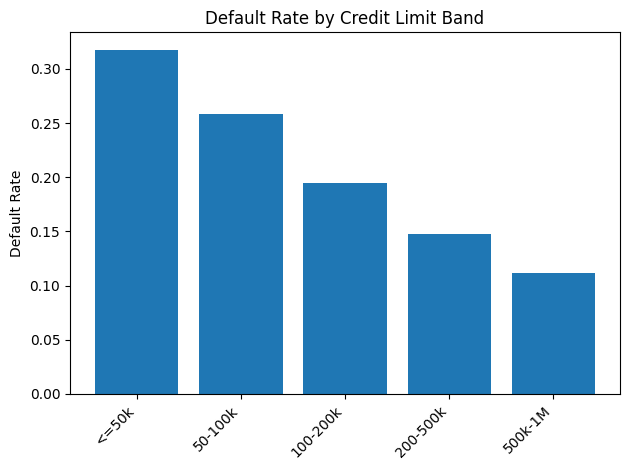

In [105]:
plt.figure()
plt.bar(dr_limit["bucket"].astype(str), dr_limit["default_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Credit Limit Band")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

4.3 Default Rate by Delinquency Severity.

In [106]:
dr_delay = df.groupby("max_delay")["DEFAULT"].agg(["count","mean"]).reset_index()
dr_delay = dr_delay.rename(columns={"mean": "default_rate"})
dr_delay

,max_delay,count,default_rate
0,-2,2109,0.134661
1,-1,3086,0.147116
2,0,14736,0.108306
3,1,1689,0.249852
4,2,7187,0.435509
5,3,789,0.622307
6,4,218,0.642202
7,5,69,0.507246
8,6,25,0.560000
9,7,67,0.835821


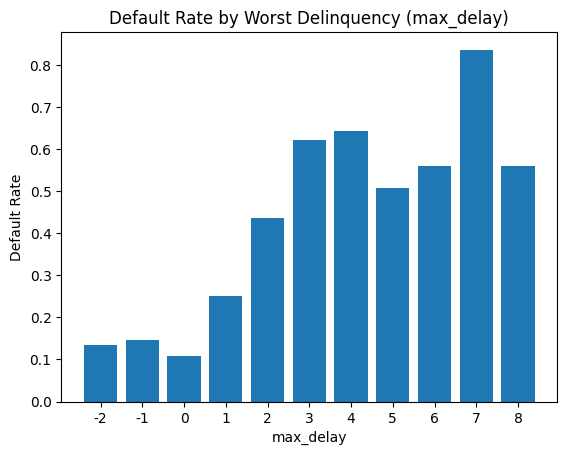

In [107]:
plt.figure()
plt.bar(dr_delay["max_delay"].astype(str), dr_delay["default_rate"])
plt.title("Default Rate by Worst Delinquency (max_delay)")
plt.xlabel("max_delay")
plt.ylabel("Default Rate")
plt.show()

4.4 Default Rate by Payment-to-Bill Ratio

In [108]:
tmp = df.dropna(subset=["payment_bill_ratio"]).copy()

ratio_bins = [-np.inf, 0.25, 0.5, 0.75, 1.0, 1.5, np.inf]
ratio_labels = ["<0.25","0.25-0.5","0.5-0.75","0.75-1.0","1.0-1.5",">1.5"]

dr_ratio = default_rate_by_bucket(tmp, "payment_bill_ratio", ratio_bins, ratio_labels)
dr_ratio

/tmp/ipykernel_164/814744390.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")["DEFAULT"].agg(["count","mean"]).reset_index()


,bucket,count,default_rate
0,<0.25,19051,0.261771
1,0.25-0.5,2617,0.149026
2,0.5-0.75,2116,0.157845
3,0.75-1.0,3278,0.152532
4,1.0-1.5,2141,0.138253
5,>1.5,797,0.161857


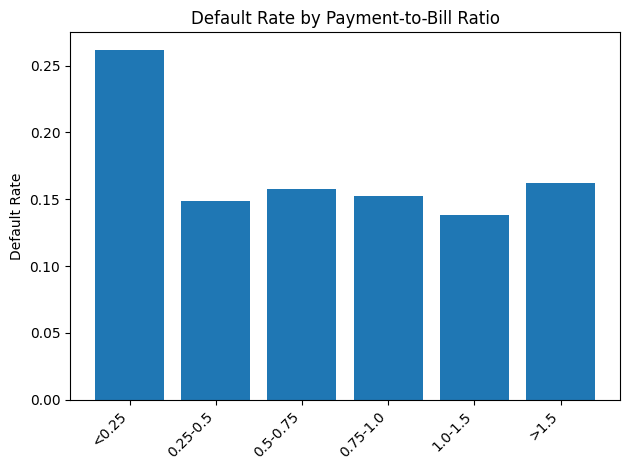

In [109]:
plt.figure()
plt.bar(dr_ratio["bucket"].astype(str), dr_ratio["default_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Payment-to-Bill Ratio")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

4.5 Default Rate by Utilization.

In [110]:
util_bins = [-np.inf, 0, 0.1, 0.3, 0.6, 1.0, np.inf]
util_labels = ["<0","0-0.1","0.1-0.3","0.3-0.6","0.6-1.0",">1.0"]

dr_util = default_rate_by_bucket(df, "utilization", util_bins, util_labels)
dr_util

/tmp/ipykernel_164/814744390.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby("bucket")["DEFAULT"].agg(["count","mean"]).reset_index()


,bucket,count,default_rate
0,<0,1071,0.343604
1,0-0.1,9975,0.171429
2,0.1-0.3,4221,0.154703
3,0.3-0.6,5470,0.219744
4,0.6-1.0,8626,0.288083
5,>1.0,637,0.342229


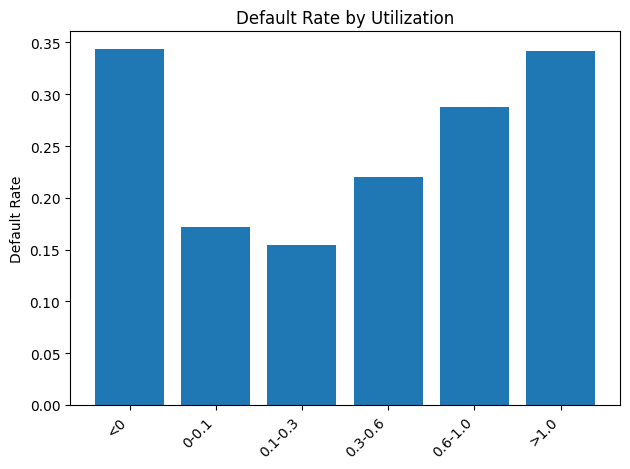

In [111]:
plt.figure()
plt.bar(dr_util["bucket"].astype(str), dr_util["default_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Default Rate by Utilization")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

## 5. Logistic Regression Model

5.1 Prepare the X, y sets.

In [112]:
target = "DEFAULT"

cat_cols = ["SEX","EDUCATION","MARRIAGE"]
num_cols = ["AGE","LIMIT_BAL"] + engineered + pay_cols

X = df[cat_cols + num_cols].copy()
y = df[target].copy()

# One-hot encode categoricals
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Replace inf and handle NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

5.2 Perform train and test split.

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

5.3 Scale the numeric features.

In [114]:
scaler = StandardScaler(with_mean=False)  # with_mean=False is safer with sparse-ish dummies
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5.4 Train the logistic regression model.

In [115]:
logit = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
logit.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

In [116]:
logit = LogisticRegression(max_iter=2000) # WITHOUT CLASS WEIGHT
logit.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

5.5 Predict PD and evaluate the results.

In [117]:
pd_test = logit.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, pd_test)
auc

np.float64(0.7551961784944794)

5.6 Plot the ROC curve.

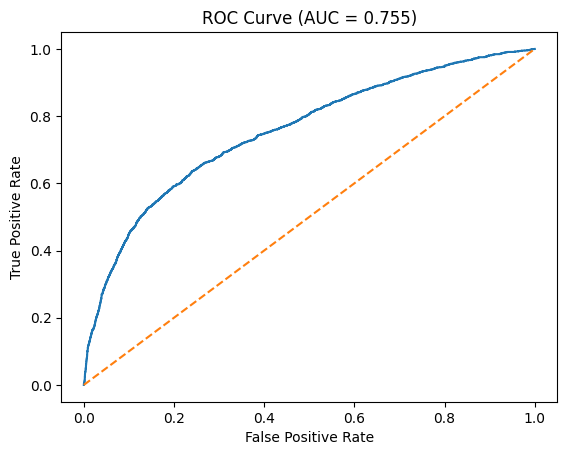

In [118]:
fpr, tpr, _ = roc_curve(y_test, pd_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

5.7 Obtain the confusion matrix.

In [119]:
y_pred = (pd_test >= 0.5).astype(int)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      7009
           1       0.64      0.29      0.40      1991

    accuracy                           0.81      9000
   macro avg       0.73      0.62      0.64      9000
weighted avg       0.78      0.81      0.78      9000



## 6. Neural Network Model (Comparison)

6.1 Scale the numeric features (on train/test sets).

In [120]:
scaler = StandardScaler()  # now allow centering
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

6.2 Train the neural network model.

In [121]:
nn = MLPClassifier(
    hidden_layer_sizes=(32, 16),   # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)

6.3 Predict PD and evaluate the results.

In [122]:
pd_test_nn = nn.predict_proba(X_test_scaled)[:, 1]

auc_nn = roc_auc_score(y_test, pd_test_nn)
auc_nn

np.float64(0.7490785507246585)

6.4 Plot the ROC curve.

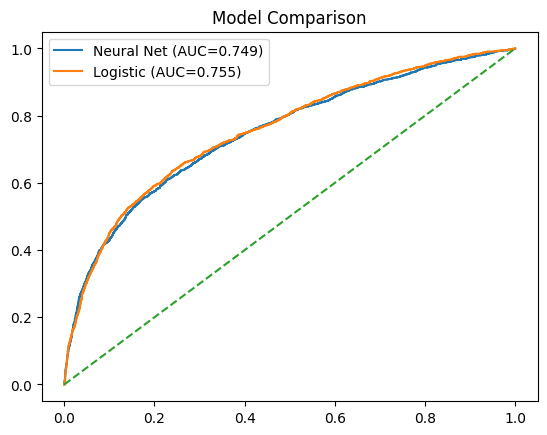

In [123]:
fpr_nn, tpr_nn, _ = roc_curve(y_test, pd_test_nn)

plt.figure()
plt.plot(fpr_nn, tpr_nn, label=f"Neural Net (AUC={auc_nn:.3f})")
plt.plot(fpr, tpr, label=f"Logistic (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Model Comparison")
plt.show()

6.5 Obtain the confusion matrix.

In [124]:
y_pred_nn = (pd_test_nn >= 0.5).astype(int)
confusion_matrix(y_test, y_pred_nn)
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      7009
           1       0.61      0.36      0.46      1991

    accuracy                           0.81      9000
   macro avg       0.73      0.65      0.67      9000
weighted avg       0.79      0.81      0.79      9000



## 7. Risk Segmentation for PD

7.1 Score everyone.

In [125]:
pd_all = logit.predict_proba(scaler.transform(X))[:, 1]
df["PD"] = pd_all

7.2 Create PD bands.

In [126]:
bins = [0, 0.05, 0.10, 0.20, 0.40, 1.01]
labels = ["S1 Very Low (<5%)", "S2 Low (5-10%)", "S3 Medium (10-20%)",
          "S4 High (20-40%)", "S5 Very High (40%+)"]

df["risk_segment"] = pd.cut(df["PD"], bins=bins, labels=labels, include_lowest=True)

7.3 Segment profile table

In [127]:
segment_profile = df.groupby("risk_segment").agg(
    customers=("DEFAULT","count"),
    avg_PD=("PD","mean"),
    default_rate=("DEFAULT","mean"),
    avg_limit=("LIMIT_BAL","mean"),
    avg_util=("utilization","mean"),
    avg_max_delay=("max_delay","mean"),
    avg_delay_count=("delay_count","mean"),
    avg_pay_ratio=("payment_bill_ratio","mean")
).reset_index()

segment_profile

/tmp/ipykernel_164/882390465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_profile = df.groupby("risk_segment").agg(


,risk_segment,customers,avg_PD,default_rate,avg_limit,avg_util,avg_max_delay,avg_delay_count,avg_pay_ratio
0,S1 Very Low (<5%),142,0.034591,0.049296,415352.112676,0.308507,-0.267606,0.042254,15.461009
1,S2 Low (5-10%),747,0.080499,0.065596,353574.297189,0.246360,-0.231593,0.001339,1.094077
2,S3 Medium (10-20%),6394,0.161411,0.077729,280168.908352,0.205589,-0.306537,0.005630,0.541261
3,S4 High (20-40%),13713,0.256205,0.144753,136595.469992,0.395266,-0.223000,0.085320,0.384390
4,S5 Very High (40%+),9004,0.627152,0.455131,115159.484673,0.469656,2.042537,2.644713,0.301047


7.4 Share of portfolio.

In [128]:
segment_profile["share"] = segment_profile["customers"] / segment_profile["customers"].sum()
segment_profile

,risk_segment,customers,avg_PD,default_rate,avg_limit,avg_util,avg_max_delay,avg_delay_count,avg_pay_ratio,share
0,S1 Very Low (<5%),142,0.034591,0.049296,415352.112676,0.308507,-0.267606,0.042254,15.461009,0.004733
1,S2 Low (5-10%),747,0.080499,0.065596,353574.297189,0.246360,-0.231593,0.001339,1.094077,0.024900
2,S3 Medium (10-20%),6394,0.161411,0.077729,280168.908352,0.205589,-0.306537,0.005630,0.541261,0.213133
3,S4 High (20-40%),13713,0.256205,0.144753,136595.469992,0.395266,-0.223000,0.085320,0.384390,0.457100
4,S5 Very High (40%+),9004,0.627152,0.455131,115159.484673,0.469656,2.042537,2.644713,0.301047,0.300133


## 8. Clustering within Medium/High Risk

8.1 Filter to Medium+ risk (example: PD ≥ 0.10).

In [129]:
mh = df[df["PD"] >= 0.10].copy()

8.2 Choose clustering features (behavioral only).

In [130]:
cluster_features = ["utilization", "bill_trend", "payment_bill_ratio", "delay_count", "max_delay"]

C = mh[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)

sc = StandardScaler()
C_scaled = sc.fit_transform(C)

8.3 KMeans clustering.

In [133]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
mh["persona_cluster"] = kmeans.fit_predict(C_scaled)

8.4 Profile clusters (personas).

In [134]:
persona_profile = mh.groupby("persona_cluster").agg(
    customers=("DEFAULT","count"),
    avg_PD=("PD","mean"),
    default_rate=("DEFAULT","mean"),
    avg_util=("utilization","mean"),
    avg_bill_trend=("bill_trend","mean"),
    avg_pay_ratio=("payment_bill_ratio","mean"),
    avg_delay_count=("delay_count","mean"),
    avg_max_delay=("max_delay","mean"),
).reset_index()

persona_profile

,persona_cluster,customers,avg_PD,default_rate,avg_util,avg_bill_trend,avg_pay_ratio,avg_delay_count,avg_max_delay
0,0,13466,0.261868,0.144512,0.085711,-349.232660,0.734310,0.191074,-0.268008
1,1,7025,0.639735,0.487687,0.569641,2797.095089,0.127470,3.104484,2.283843
2,2,8620,0.251952,0.140139,0.673745,42785.526450,0.076438,0.073898,0.108817


## 9. Validation Techniques for Model

9.1 Calibration Check.

In [135]:
segment_validation = df.groupby("risk_segment").agg(
    avg_PD=("PD","mean"),
    actual_default_rate=("DEFAULT","mean"),
    customers=("DEFAULT","count")
).reset_index()

segment_validation

/tmp/ipykernel_164/65067340.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_validation = df.groupby("risk_segment").agg(


,risk_segment,avg_PD,actual_default_rate,customers
0,S1 Very Low (<5%),0.034591,0.049296,142
1,S2 Low (5-10%),0.080499,0.065596,747
2,S3 Medium (10-20%),0.161411,0.077729,6394
3,S4 High (20-40%),0.256205,0.144753,13713
4,S5 Very High (40%+),0.627152,0.455131,9004


In [136]:
segment_validation["calibration_gap"] = (
    segment_validation["avg_PD"] -
    segment_validation["actual_default_rate"]
)

segment_validation

,risk_segment,avg_PD,actual_default_rate,customers,calibration_gap
0,S1 Very Low (<5%),0.034591,0.049296,142,-0.014705
1,S2 Low (5-10%),0.080499,0.065596,747,0.014903
2,S3 Medium (10-20%),0.161411,0.077729,6394,0.083682
3,S4 High (20-40%),0.256205,0.144753,13713,0.111452
4,S5 Very High (40%+),0.627152,0.455131,9004,0.172021


9.2 Lift Analysis.

In [137]:
overall_default = df["DEFAULT"].mean()
overall_default

np.float64(0.2212)

In [138]:
segment_validation["lift"] = (
    segment_validation["actual_default_rate"] /
    overall_default
)

segment_validation

,risk_segment,avg_PD,actual_default_rate,customers,calibration_gap,lift
0,S1 Very Low (<5%),0.034591,0.049296,142,-0.014705,0.222856
1,S2 Low (5-10%),0.080499,0.065596,747,0.014903,0.296545
2,S3 Medium (10-20%),0.161411,0.077729,6394,0.083682,0.351397
3,S4 High (20-40%),0.256205,0.144753,13713,0.111452,0.654399
4,S5 Very High (40%+),0.627152,0.455131,9004,0.172021,2.057554


9.3 Cumulative Gain / Top-Risk Capture.

In [139]:
df_sorted = df.sort_values("PD", ascending=False).reset_index(drop=True)
df_sorted["cum_default"] = df_sorted["DEFAULT"].cumsum()
df_sorted["cum_population"] = np.arange(1, len(df_sorted)+1)

In [140]:
top_20 = int(0.2 * len(df_sorted))

capture_rate = (
    df_sorted.iloc[:top_20]["DEFAULT"].sum() /
    df_sorted["DEFAULT"].sum()
)

capture_rate

np.float64(0.4924653405666064)

9.4 Stability of Risk Drivers Across Segments.

In [143]:
validation_profile = df.groupby("risk_segment").agg(
    avg_limit=("LIMIT_BAL","mean"),
    avg_utilization=("utilization","mean"),
    avg_max_delay=("max_delay","mean"),
    avg_delay_count=("delay_count","mean"),
    avg_payment_ratio=("payment_bill_ratio","mean"),
    default_rate=("DEFAULT","mean")
).reset_index()

validation_profile

/tmp/ipykernel_164/985432247.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  validation_profile = df.groupby("risk_segment").agg(


,risk_segment,avg_limit,avg_utilization,avg_max_delay,avg_delay_count,avg_payment_ratio,default_rate
0,S1 Very Low (<5%),415352.112676,0.308507,-0.267606,0.042254,15.461009,0.049296
1,S2 Low (5-10%),353574.297189,0.246360,-0.231593,0.001339,1.094077,0.065596
2,S3 Medium (10-20%),280168.908352,0.205589,-0.306537,0.005630,0.541261,0.077729
3,S4 High (20-40%),136595.469992,0.395266,-0.223000,0.085320,0.384390,0.144753
4,S5 Very High (40%+),115159.484673,0.469656,2.042537,2.644713,0.301047,0.455131


9.5 KS Statistic (Gold Standard in Credit Risk).

In [142]:
from scipy.stats import ks_2samp

ks_stat = ks_2samp(
    df[df["DEFAULT"]==1]["PD"],
    df[df["DEFAULT"]==0]["PD"]
).statistic

ks_stat

np.float64(0.41013213942842774)

## EXTRA: Isotonic Regression for Calibration Issues

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base logistic model (no class_weight)
base_logit = LogisticRegression(max_iter=2000)
base_logit.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [145]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate using isotonic regression
calibrated_model = CalibratedClassifierCV(
    base_logit,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train_scaled, y_train)

CalibratedClassifierCV(cv=5, estimator=LogisticRegression(max_iter=2000),
                       method='isotonic')

In [146]:
pd_test_cal = calibrated_model.predict_proba(X_test_scaled)[:, 1]

In [147]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred_cal = (pd_test_cal >= 0.5).astype(int)

confusion_matrix(y_test, y_pred_cal)
print(classification_report(y_test, y_pred_cal))

              precision    recall  f1-score   support

           0       0.83      0.95      0.88      7009
           1       0.63      0.32      0.42      1991

    accuracy                           0.81      9000
   macro avg       0.73      0.63      0.65      9000
weighted avg       0.79      0.81      0.78      9000



In [148]:
roc_auc_score(y_test, pd_test_cal)

np.float64(0.7550693414988652)

In [149]:
df["PD_calibrated"] = calibrated_model.predict_proba(
    scaler.transform(X)
)[:,1]

In [150]:
segment_validation_cal = df.groupby("risk_segment").agg(
    avg_PD_calibrated=("PD_calibrated","mean"),
    actual_default_rate=("DEFAULT","mean"),
    customers=("DEFAULT","count")
).reset_index()

segment_validation_cal["calibration_gap"] = (
    segment_validation_cal["avg_PD_calibrated"] -
    segment_validation_cal["actual_default_rate"]
)

segment_validation_cal

/tmp/ipykernel_164/288209724.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_validation_cal = df.groupby("risk_segment").agg(


,risk_segment,avg_PD_calibrated,actual_default_rate,customers,calibration_gap
0,S1 Very Low (<5%),0.021043,0.049296,142,-0.028253
1,S2 Low (5-10%),0.053079,0.065596,747,-0.012517
2,S3 Medium (10-20%),0.076910,0.077729,6394,-0.000819
3,S4 High (20-40%),0.141509,0.144753,13713,-0.003244
4,S5 Very High (40%+),0.460597,0.455131,9004,0.005465


In [151]:
comparison = df.groupby("risk_segment").agg(
    avg_PD_raw=("PD","mean"),
    avg_PD_calibrated=("PD_calibrated","mean"),
    actual_default_rate=("DEFAULT","mean")
).reset_index()

comparison

/tmp/ipykernel_164/3369018672.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison = df.groupby("risk_segment").agg(


,risk_segment,avg_PD_raw,avg_PD_calibrated,actual_default_rate
0,S1 Very Low (<5%),0.034591,0.021043,0.049296
1,S2 Low (5-10%),0.080499,0.053079,0.065596
2,S3 Medium (10-20%),0.161411,0.076910,0.077729
3,S4 High (20-40%),0.256205,0.141509,0.144753
4,S5 Very High (40%+),0.627152,0.460597,0.455131
